## F1 UNDERCUT ANALYSIS
**Aim is to explore data to help develop a methodology for calculating individual circuit undercut strength.**

In [1]:
import fastf1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, MultipleLocator

import warnings

warnings.filterwarnings("ignore")


fastf1.Cache.enable_cache("/Users/ethan/dev/formation_lap/.cache/fastf1")

I am choosing Miami 2026. Reason: It's a race from the new regs which is going to be most critical for analysis. The race had notable strategy battles and no safety cars to disrupt it. Miami will act as a base. Other interesting tracks include Bahrain(deg heavy), Monaco(undercut is key) and Catalunya(typical benchmark track).

In [2]:
session = fastf1.get_session(2026, "Miami", "R")
session.load()

core           INFO 	Loading data for Miami Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	Driver 12 completed the race distance 00:00.027000 before the recorded end of the session.
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 22 drivers: ['12', '1', '81', '63', '3', '44', '43', '16', '55', '23', '87', '5',

I want to isolate some specific battles. It would be easiest to work backwards, isolating battles and then analyising how these battles could have been identified via the data. The key battle in Miami 2026 was Norris and Antonelli, with Norris finishing just 3.2 seconds behind. I will first visualise cleaned lap time data with stint information.

Text(0.5, 1.0, 'NORRIS - 2026 Miami GP')

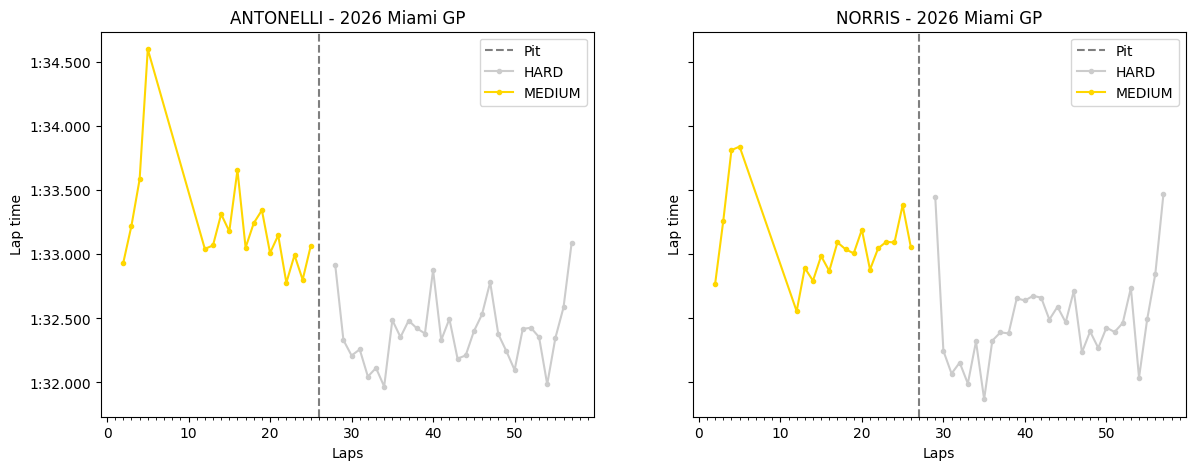

In [3]:
compounds = {"SOFT": "#FF3333", "MEDIUM": "#FFD700", "HARD": "#CCCCCC"}

ant = session.laps.pick_drivers("ANT")
nor = session.laps.pick_drivers("NOR")

ant["LapTime_s"] = ant["LapTime"].dt.total_seconds()
nor["LapTime_s"] = nor["LapTime"].dt.total_seconds()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5) ,sharey=True)

def lap_plot(d, ax):
    """For later use."""
    pit_laps = d[d["PitInTime"].notna()]["LapNumber"]
    d = d.pick_accurate().copy()
    for lap in pit_laps:
        ax.axvline(x=lap, color="black", linestyle="--", alpha=0.5, label="Pit")

    for compound, group in d.groupby("Compound"):
        ax.plot(
            group["LapNumber"],
            group["LapTime_s"],
            marker="o",
            markersize=3,
            linewidth=1.5,
            color=compounds.get(compound, "pink"),
            label=compound,
        )

    ax.legend()
    ax.xaxis.set_major_locator(MultipleLocator(10))
    ax.xaxis.set_minor_locator(MultipleLocator(1))
    ax.yaxis.set_major_formatter(
        FuncFormatter(lambda x, pos: f"{int(x // 60)}:{x % 60:06.3f}")
    )
    ax.set_xlabel("Laps")
    ax.set_ylabel("Lap time")


for d, ax in ((ant, ax1), (nor, ax2)):
    lap_plot(d, ax)

ax1.set_title("ANTONELLI - 2026 Miami GP")
ax2.set_title("NORRIS - 2026 Miami GP")

We can see that Antonelli pits only one lap earlier than Norris. This means we will be looking at a one lap undercut for this race. The fundamental component we need for calculuting undercut strength is how pace compares on old compounds vs fresh compounds. It can be observed that the Hard is faster for almost all of its stint compared to the Medium (likely due to fuel). This is a positive signal; it means **we don't have to consider which compound transition is taking place for our calculation.** 

I will now produce plots looking at tyre pace and degradation.

In [4]:
def get_coeffs(d):
    stints = d.groupby("Stint")

    med_stint = stints.get_group(1).copy()
    med_stint["LapTime_s"] = med_stint["LapTime"].dt.total_seconds()

    # clean
    med_stint = med_stint[
        (med_stint["LapTime_s"].notna())
        & (
            ~med_stint["TrackStatus"].isin(["4", "5", "6", "7"])
        )  # also drops transition laps (e.g '41')
        & (med_stint["TyreLife"] > 1)  # remove out-lap
        & (med_stint["PitInTime"].isna())  # remove in-lap
    ]

    coeffs = np.polyfit(med_stint["TyreLife"], med_stint["LapTime_s"], 1)
    return coeffs


ant_c, nor_c = get_coeffs(ant), get_coeffs(nor)
print(ant_c)
print(nor_c)


[ -0.35765783 100.52302808]
[-0.31293716 99.72419162]


Interesting finding here. Tyre deg is a negative value, meaning that lap time decreases lap by lap(-0.36 & -0.31). Probable causes include fuel loss (weight) and track evolution. This number is going to vary a lot at different tracks (and races from the previous regs?) - It is a key factor for our undercut calculation. 

It's worth comparing these numbers with a comparable Miami GP from the previous regs. 

core           INFO 	Loading data for Miami Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	Driver 81 completed the race distance 00:00.036000 before the recorded end of the session.
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['81', '4', '63', '1', '23', '12', '16', '44', '55', '22', '6', '31',

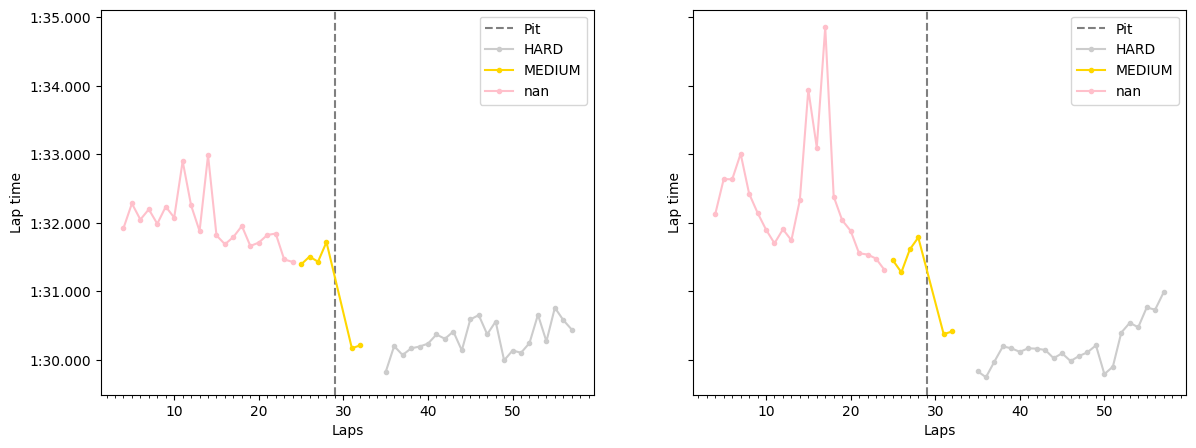

In [5]:
old_session = fastf1.get_session(2025, "miami", "R")
old_session.load()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# top 2 drivers: PIA, NOR
pia = old_session.laps.pick_drivers("PIA")
nor = old_session.laps.pick_drivers("NOR")

pia["LapTime_s"] = pia["LapTime"].dt.total_seconds()
nor["LapTime_s"] = nor["LapTime"].dt.total_seconds()

lap_plot(pia, ax1)
lap_plot(nor, ax2)


NaN values are a known issue in FastF1. We can see from the transition between NaN and Medium that there are no dropped laps for pits and therefore infer the NaN values are infact Medium. We will have to account for this issue occuring in our unsupervised data flows.

Pit lap also does not reflect the stints we see in the chart.

In [6]:
# expose the two data issues

cols = ["LapNumber", "Stint", "Compound", "TyreLife", "PitInTime", "PitOutTime"]

for label, d in [("PIA", pia), ("NOR", nor)]:
    first_pit = d[d["PitInTime"].notna()]["LapNumber"].min()
    print(f"=== {label}  (first pit: lap {first_pit:.0f}) ===")

    # Show the stint/compound view around the pit to expose both issues
    window = d[(d["LapNumber"] >= 1) & (d["LapNumber"] <= first_pit + 5)][cols].copy()
    print(window.to_string(index=False))

    nan_stints = d["Stint"].isna().sum()
    nan_compounds = d["Compound"].isna().sum()
    print(f"  NaN Stint: {nan_stints} laps | NaN Compound: {nan_compounds} laps")
    print(f"  Stints present (non-NaN): {sorted(d['Stint'].dropna().unique())}\n")

=== PIA  (first pit: lap 29) ===
 LapNumber  Stint Compound  TyreLife              PitInTime             PitOutTime
       1.0    NaN      nan       NaN                    NaT                    NaT
       2.0    NaN      nan       NaN                    NaT                    NaT
       3.0    NaN      nan       NaN                    NaT                    NaT
       4.0    NaN      nan       NaN                    NaT                    NaT
       5.0    NaN      nan       NaN                    NaT                    NaT
       6.0    NaN      nan       NaN                    NaT                    NaT
       7.0    NaN      nan       NaN                    NaT                    NaT
       8.0    NaN      nan       NaN                    NaT                    NaT
       9.0    NaN      nan       NaN                    NaT                    NaT
      10.0    NaN      nan       NaN                    NaT                    NaT
      11.0    NaN      nan       NaN                  

**Two data issues noted:**

1. **NaN Stint / NaN Compound (laps ~1–24):** FastF1's `timing_app_data` only begins tracking compound mid-race in some 2025 sessions. These laps get `Stint=NaN`, which the original `isin([0, 1])` filter silently drops — losing the bulk of the medium stint and leaving only ~4 pre-pit laps for the regression.

2. **Stint counter lag post-pit:** FastF1 increments the `Stint` number roughly 3 laps *after* the driver exits the pit. The out-lap and the two following laps are still labeled `Stint=1` despite being on fresh HARD compound, polluting the medium-stint regression.

These issues are an annoying but valuable discovery, and I wil definetly need to add extensive data quality checks and handlers for the automated calculations.

In [7]:
def get_coeffs_2025(d):
    """
    Stint-1 deg coefficient for sessions with FastF1 compound-tracking gaps.

    Two issues with Stint-number filtering in affected sessions:
    - Laps where timing_app_data has no compound get Stint=NaN and are silently
      dropped by .isin([0,1]), leaving only the few pre-pit laps FastF1 confirmed.
    - FastF1's stint counter lags ~3 laps after a pit-out, so post-pit laps are
      still labeled with the old stint and contaminate the medium-stint regression.

    Fix: use PitInTime to mark the true stint-1 boundary; fall back to LapNumber
    as a TyreLife proxy for the laps FastF1 couldn't track (assumes fresh tyres
    from lap 1 — valid for a race start on new rubber).
    """
    d = d.copy()
    d["LapTime_s"] = d["LapTime"].dt.total_seconds()

    # True stint-1 boundary: every lap before the first pit-in event (in-lap excluded)
    first_pit_lap = d[d["PitInTime"].notna()]["LapNumber"].min()
    stint1 = d[d["LapNumber"] < first_pit_lap].copy()

    n_imputed = stint1["TyreLife"].isna().sum()
    stint1["TyreLife_eff"] = stint1["TyreLife"].fillna(stint1["LapNumber"])

    clean = stint1[
        (stint1["LapTime_s"].notna())
        & (~stint1["TrackStatus"].isin(["4", "5", "6", "7"]))
        & (stint1["TyreLife_eff"] > 1)
    ]

    coeffs = np.polyfit(clean["TyreLife_eff"], clean["LapTime_s"], 1)
    print(f"  Stint 1: laps {clean['LapNumber'].min():.0f}–{clean['LapNumber'].max():.0f} "
          f"| {len(clean)} clean laps ({n_imputed} TyreLife values imputed from LapNumber)")
    print(f"  deg = {coeffs[0]:+.4f} s/lap  |  base = {coeffs[1]:.3f} s")
    return coeffs


print("=== 2025 Miami — corrected stint-1 deg coefficients ===\n")
coeffs_2025 = []
for label, d in [("PIA", pia), ("NOR", nor)]:
    print(f"{label}:")
    c = get_coeffs_2025(d)
    coeffs_2025.append(c)
    print()

=== 2025 Miami — corrected stint-1 deg coefficients ===

PIA:
  Stint 1: laps 2–28 | 26 clean laps (24 TyreLife values imputed from LapNumber)
  deg = -0.3957 s/lap  |  base = 98.683 s

NOR:
  Stint 1: laps 2–28 | 26 clean laps (24 TyreLife values imputed from LapNumber)
  deg = -0.3842 s/lap  |  base = 98.798 s



Comparing 2026 vs 2025:
- 2025 deg coefficient is more negative (faster improvement per lap) — This suggests the new cars tyre deg is **more important**. It could also be due lighter cars with a higher energy split burning less fuel.
- Both years show a negative coefficient: fuel load / track evolution dominate over tyre degradation on medium compound at Miami

This `LapNumber`-as-`TyreLife` proxy works reliably for **race starts on new rubber**. It would need adjusting for drivers who carry qualifier tyres into a race. Data verification module may be needed. 

We have identified that lap time decreases lap by lap **less** in 2026 compared to 2025. We could also look to the impact of weather, track fuel levels etc, but that's overkill here. Importantly, the values are both negative and both reasonably close to eachother (for 2026 vs 2025). This means even without accounting for season, our undercut calculation can remain reasonably accurate. We could also identify these coeffecients for each season in the calculation instead of using an average value. 

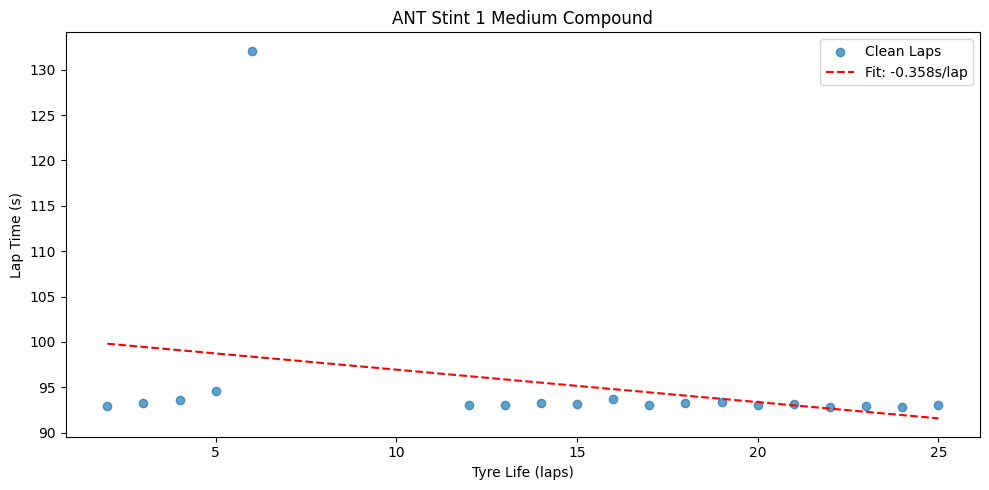

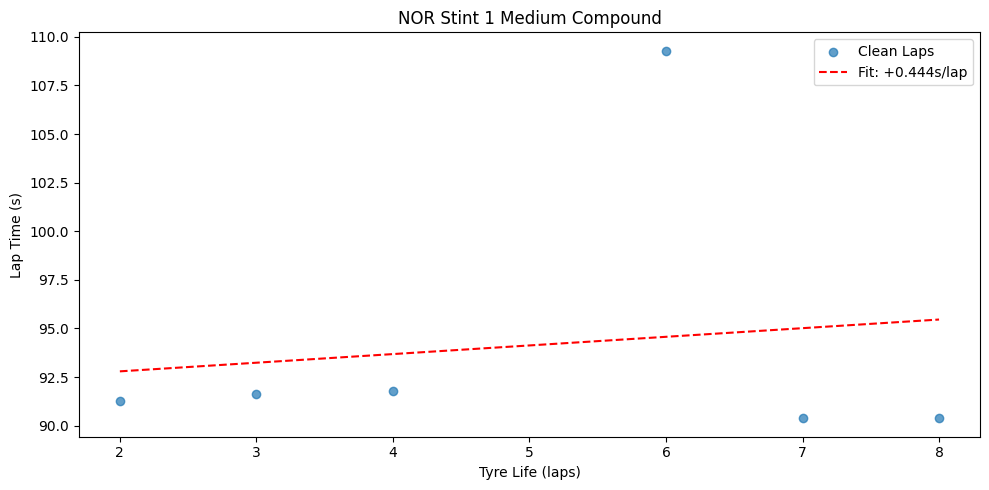

In [8]:

# extended function required
def plot_coeffs(d, s: int, title):
    stints = d.groupby("Stint")

    stint = stints.get_group(s).copy()
    stint["LapTime_s"] = stint["LapTime"].dt.total_seconds()

    clean = stint[
        (stint["LapTime_s"].notna())
        & (
            ~stint["TrackStatus"].isin(["4", "5", "6", "7"])
        )  # also drops transition laps (e.g '41')
        & (stint["TyreLife"] > 1)  # remove out-lap
        & (stint["PitInTime"].isna())  # remove in-lap
    ]

    coeffs = np.polyfit(clean["TyreLife"], clean["LapTime_s"], 1)
    deg_rate, base = coeffs

    x_fit = np.linspace(clean["TyreLife"].min(), clean["TyreLife"].max(), 50)
    y_fit = np.polyval(coeffs, x_fit)

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.scatter(clean["TyreLife"], clean["LapTime_s"], label="Clean Laps", alpha=0.7)
    ax.plot(x_fit, y_fit, "r--", label=f"Fit: {deg_rate:+.3f}s/lap")
    ax.set_xlabel("Tyre Life (laps)")
    ax.set_ylabel("Lap Time (s)")
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()

plot_coeffs(ant, 1, "ANT Stint 1 Medium Compound")
plot_coeffs(nor, 1, "NOR Stint 1 Medium Compound")

There are more sample issues in NOR's 2026 running. I am going to disregard at this stage as the general picture can be gleaned from Antonellis running.

## From a degradation slope to undercut strength

The slopes above (`get_coeffs`) bundle three effects (fuel burn, track evolution and tyre degradation) into one number, and they have come out *negative* (the car gets faster as the stint runs). It's known that cars get faster through a race due to fuel burn. What's noteworthy is that this translate directly to a negative coeffecient. For undercut strength I need to isolate the one thing pitting actually buys back: **how much pace a fresh tyre has over a worn one at the same fuel load.**

Walk through a covered one-lap undercut. Car B (behind) pits at the end of lap *L*; car A (ahead) reacts and pits at the end of lap *L+1*. Strip out the fixed pit-lane transit time — both cars pay it once, so it cancels — and line the laps up:

| lap | car B | car A |
|---|---|---|
| L | worn (in-lap) | worn |
| L+1 | **fresh** (out-lap) | **worn** |
| L+2 | fresh | fresh (out-lap) |


> **one-lap undercut gain ≈ (worn-tyre pace) − (fresh-tyre pace), at equal fuel.**

That's the quantity I want per circuit. First question: can I just measure fuel and degradation separately and subtract?

In [9]:
# Can I just regress fuel and degradation apart? Pool the field's green laps and fit
#   LapTime ~ LapNumber (fuel/evolution) + TyreLife (degradation)
# per compound, and look at the coefficients + how collinear the two inputs are.

def green_flying(laps):
    """Green-flag flying laps: valid time, no in/out-lap, no SC/VSC/red, TyreLife>1."""
    d = laps.copy()
    d["LapTime_s"] = d["LapTime"].dt.total_seconds()
    return d[
        d["LapTime_s"].notna()
        & d["PitInTime"].isna()
        & d["PitOutTime"].isna()
        & ~d["TrackStatus"].astype(str).str.contains("[4567]", regex=True)
        & (d["TyreLife"] > 1)
    ]


gf = green_flying(session.laps)
for comp in ("MEDIUM", "HARD"):
    g = gf[gf["Compound"] == comp].dropna(subset=["LapNumber", "TyreLife", "LapTime_s"])
    g = g[g["LapTime_s"] < g["LapTime_s"].median() * 1.07]  # drop traffic/damage laps
    r = g["LapNumber"].corr(g["TyreLife"])
    X = np.column_stack([np.ones(len(g)), g["LapNumber"].values, g["TyreLife"].values])
    _, fuel, deg = np.linalg.lstsq(X, g["LapTime_s"].values, rcond=None)[0]
    print(f"{comp:7s}: corr(LapNumber, TyreLife)={r:+.2f}  "
          f"fuel={fuel:+.3f} s/lap   deg={deg:+.3f} s/lap   (n={len(g)})")

MEDIUM : corr(LapNumber, TyreLife)=+0.84  fuel=+0.143 s/lap   deg=-0.125 s/lap   (n=355)
HARD   : corr(LapNumber, TyreLife)=+0.72  fuel=+0.016 s/lap   deg=-0.009 s/lap   (n=445)


As expected: `fuel` and `deg` come out as near-perfect mirror images (e.g. one is +X, the other −X) and the correlation is high. Within a stint `TyreLife = LapNumber − stint_start`, so on a one-stop race the two columns are basically the same variable and the regression can't tell them apart. **In a one-stop race you cannot cleanly separate fuel burn from tyre degradation.**

But I don't actually need to. The undercut gain is a *worn vs fresh* comparison at **similar fuel** and I can get that almost for free by sampling the last few laps before the stop and the first few green laps after it. Those pools are only ~5 laps apart, so fuel only needs a tiny correction (a known ballpark constant), not a full decomposition. 

So the recipe is:
1. take the green-flag flying laps either side of each pit stop (keyed off `PitInTime`/`PitOutTime`, **not** the flaky `Stint` counter),
2. `fresh_advantage = median(worn pace) − median(fresh pace)`, nudged for the small fuel difference,
3. take a robust central value across the field → the circuit's undercut strength.

In [10]:
# Undercut strength = robust median fresh-tyre pace advantage per lap of stop offset.
# Light fuel correction; worn/fresh samples sit ~5 laps apart so the metric is
# insensitive to it (sensitivity shown two cells down).
FUEL_RATE = -0.06  # s/lap of pace improvement from burning fuel


def fresh_tyre_advantage(session, fuel_rate=FUEL_RATE, n=3):
    """One row per clean green-flag pit stop: fuel-corrected pace gain from worn
    tyres (last `n` laps before the in-lap) to fresh (laps 2..n+1 after the out-lap).

    Keys off PitInTime/PitOutTime + TyreLife only — never the unreliable Stint
    counter (see the 2025 data-quality findings above).
    """
    gf = green_flying(session.laps)
    rows = []
    for drv, dall in session.laps.groupby("Driver"):
        dall = dall.sort_values("LapNumber")
        g = gf[gf["Driver"] == drv]
        for L in dall.loc[dall["PitInTime"].notna(), "LapNumber"]:
            worn = g[(g["LapNumber"] >= L - n - 1) & (g["LapNumber"] < L)]
            fresh = g[(g["LapNumber"] > L + 1) & (g["LapNumber"] <= L + 1 + n)]  # skip out-lap
            if len(worn) < 2 or len(fresh) < 2:
                continue
            dlap = fresh["LapNumber"].mean() - worn["LapNumber"].mean()
            # project both pools to a common fuel load, then take the tyre delta
            adv = (worn["LapTime_s"].median() - fresh["LapTime_s"].median()) + fuel_rate * dlap
            from_comp = worn["Compound"].dropna().iloc[-1] if worn["Compound"].notna().any() else None
            rows.append({"drv": drv, "pit_lap": int(L), "from": from_comp, "fresh_adv": round(adv, 3)})
    return pd.DataFrame(rows)


def undercut_strength(session, fuel_rate=FUEL_RATE):
    """Circuit undercut strength (s): the tyre-degradation engine of the undercut."""
    df = fresh_tyre_advantage(session, fuel_rate)
    vals = df.loc[df["fresh_adv"] > -0.5, "fresh_adv"]  # drop off-plan / anomalous switches
    return float(np.median(vals)), df


us, df = undercut_strength(session)
print(df.sort_values("fresh_adv", ascending=False).to_string(index=False))
print(f"\nMiami 2026 undercut_strength = {us:.3f} s per lap of stop offset")

drv  pit_lap   from  fresh_adv
ALO       41 MEDIUM      1.790
LIN       28 MEDIUM      1.460
SAI       28 MEDIUM      1.428
PIA       28 MEDIUM      1.283
OCO       31 MEDIUM      1.269
PER       29 MEDIUM      1.218
BOR       32 MEDIUM      1.104
HAM       27 MEDIUM      1.082
ALB       27 MEDIUM      0.941
COL       31 MEDIUM      0.899
BEA       26 MEDIUM      0.890
NOR       27 MEDIUM      0.519
STR       37   SOFT      0.492
STR       21 MEDIUM      0.444
ANT       26 MEDIUM      0.237
BOT       21   SOFT      0.055
RUS       20 MEDIUM     -0.150
LEC       21 MEDIUM     -0.228
BOT       30 MEDIUM     -1.661

Miami 2026 undercut_strength = 0.920 s per lap of stop offset


A few things stand out in the 2026 table:

- The midfield (LIN, SAI, PIA, OCO) shows the biggest fresh-tyre advantage (~1.3–1.6 s) while the front-runners (ANT, NOR, RUS) show less (~0.2–0.5 s). The leaders were cruising in clean air and managing the mediums, so their *worn* pace was already close to their fresh pace. A robust median (rather than a mean) keeps these from dragging the estimate around.
- The `SOFT`-start rows (STR, BOT) and the lone negative (LEC, BOT's second stop) are off-plan / different-compound stints — the `> -0.5 s` trim and the median absorb them.
- Net result for **Miami 2026: ~0.9 s of undercut per lap of stop offset.** Moderate — Miami is not a brutal undercut track, which squares with the low degradation the stint plots showed.

Next I'll check this is stable across seasons and not overly sensitive to my fuel assumption.

core           INFO 	Loading data for Miami Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['4', '1', '16', '11', '55', '44', '22', '63', '14', '31', '27', '10', '81', '24', '3', '77', '18', '23', '20', '2']
core           INFO 	Loading data for Miami Grand Prix - Race [v

Miami undercut strength by season:
  2024: 0.608 s
  2025: 1.100 s
  2026: 0.920 s

Fuel-rate sensitivity (2026):
  fuel_rate=-0.03  ->  1.085 s
  fuel_rate=-0.06  ->  0.920 s
  fuel_rate=-0.09  ->  0.755 s


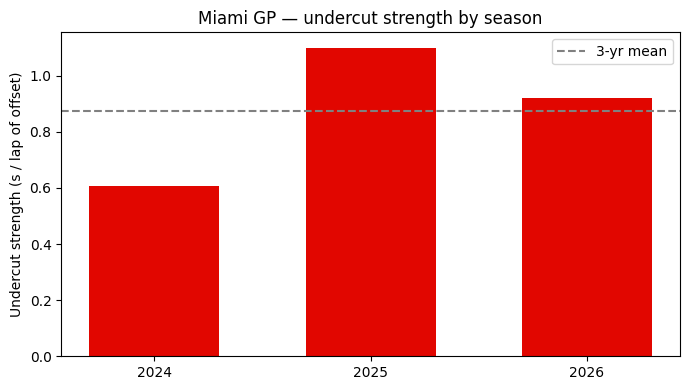

In [11]:
# Cross-season stability + fuel-rate sensitivity
years = [2024, 2025, 2026]
results = {}
for y in years:
    s = fastf1.get_session(y, "Miami", "R")
    s.load()
    results[y], _ = undercut_strength(s)

print("Miami undercut strength by season:")
for y in years:
    print(f"  {y}: {results[y]:.3f} s")

print("\nFuel-rate sensitivity (2026):")
for fr in (-0.03, -0.06, -0.09):
    v, _ = undercut_strength(session, fuel_rate=fr)
    print(f"  fuel_rate={fr:+.2f}  ->  {v:.3f} s")

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar([str(y) for y in years], [results[y] for y in years], color="#E10600", width=0.6)
ax.axhline(np.mean(list(results.values())), ls="--", color="grey", label="3-yr mean")
ax.set_ylabel("Undercut strength (s / lap of offset)")
ax.set_title("Miami GP — undercut strength by season")
ax.legend()
plt.tight_layout()

### Cross-season stability + fuel sensitivity

That's the behaviour I want from a circuit property. Miami lands at ~0.6–1.1 s every season, even across the regs change, so caching one value per circuit is defensible. And because the worn/fresh pools sit only ~5 laps apart, the fuel correction is just a nudge — sweeping `fuel_rate` from −0.03 to −0.09 moves the metric by only ~±0.16 s, so the result doesn't hinge on getting the constant exactly right.

Now the real test: does this number actually explain the NOR/ANT undercut I started from?

NOR led ANT by 2.17s before the stops (lap 25, both on worn mediums).
After both had stopped (lap 31) NOR trailed by 1.12s.
Realised swing to ANT, the undercutter: +3.28s

Decomposition:
  intrinsic tyre undercut (model)      ~+0.92s
  NOR out-lap penalty vs ANT            +1.55s  (cold tyres + traffic, stopping 1 lap later)
  remainder                             ~+0.81s  (clean air on ANT's out-lap / track position)


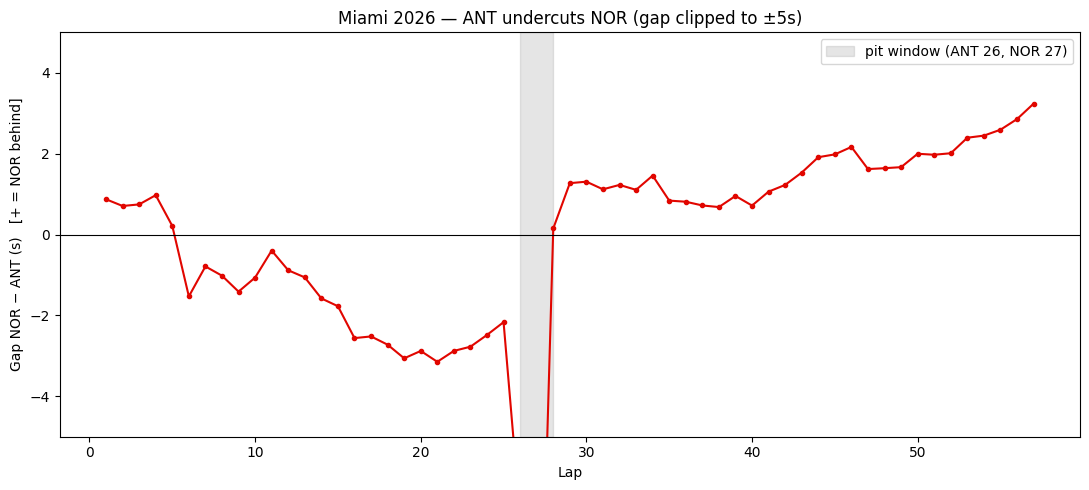

In [12]:
# Validation: does the model explain the actual NOR/ANT undercut?
# Both ran identical ~93s mediums in stint 1, so this is a clean equal-pace test.
laps26 = session.laps.copy()
laps26["LapTime_s"] = laps26["LapTime"].dt.total_seconds()


def cum_time(drv):
    d = laps26[laps26["Driver"] == drv].sort_values("LapNumber")
    return d.set_index("LapNumber")["Time"].dt.total_seconds()


gap = (cum_time("NOR") - cum_time("ANT")).dropna()  # +ve => NOR behind ANT

ant_outlap = laps26[(laps26.Driver == "ANT") & (laps26.LapNumber == 27)]["LapTime_s"].iloc[0]
nor_outlap = laps26[(laps26.Driver == "NOR") & (laps26.LapNumber == 28)]["LapTime_s"].iloc[0]
intrinsic, _ = undercut_strength(session)

pre, post = gap.loc[25], gap.loc[31]
print(f"NOR led ANT by {-pre:.2f}s before the stops (lap 25, both on worn mediums).")
print(f"After both had stopped (lap 31) NOR trailed by {post:.2f}s.")
print(f"Realised swing to ANT, the undercutter: {post - pre:+.2f}s\n")
print("Decomposition:")
print(f"  intrinsic tyre undercut (model)      ~{intrinsic:+.2f}s")
print(f"  NOR out-lap penalty vs ANT            {nor_outlap - ant_outlap:+.2f}s  (cold tyres + traffic, stopping 1 lap later)")
print(f"  remainder                             ~{(post - pre) - intrinsic - (nor_outlap - ant_outlap):+.2f}s  (clean air on ANT's out-lap / track position)")

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(gap.index, gap.values, marker="o", ms=3, color="#E10600")
ax.axhline(0, color="black", lw=0.8)
ax.axvspan(26, 28, color="grey", alpha=0.2, label="pit window (ANT 26, NOR 27)")
ax.set_ylim(-5, 5)  # clip the in/out-lap pit spikes to focus on the racing gap
ax.set_xlabel("Lap")
ax.set_ylabel("Gap NOR − ANT (s)   [+ = NOR behind]")
ax.set_title("Miami 2026 — ANT undercuts NOR (gap clipped to ±5s)")
ax.legend()
plt.tight_layout()

### Verdict

The NOR/ANT swing confirms the model is the *right shape* but is only one component of a realised undercut. Splitting it out:

| component | size | circuit-intrinsic? |
|---|---|---|
| tyre-degradation undercut (this metric) | ~0.9 s | **yes** — repeatable, ~0.6–1.1 s at Miami across 3 seasons |
| out-lap penalty (cold tyres + traffic for the later stopper) | ~1.5 s | partly — depends on field density / track position |
| clean air on the early stopper's out-lap | remainder | no — situational |

So I'll define **`undercut_strength` = the fresh-tyre pace advantage per lap of stop offset (seconds)**. It is the clean, repeatable, model-able term; there are many other factors that contribute to the *success* of an undercut, but quantifying this is a different job. The difference between Antonelli's undercut with fresh air is large. Could be worth producing an undercut range instead of a single value.

**Things to remember before it goes into the pipeline:**
- `Stint` metric is grossly unreliable for the first stint. Avoid it.
- Consider adjusting schema to store a min, median max. Or just a tuple, noting median along with a +- value.